In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler


In [ ]:
# Data loading & cleaning
df = pd.read_csv("../Modified_Pupilometri/NPImeaures_noCHerror.csv")

df["eye"] = df["eye"].map({"left": 0, "right": 1})
df["redcap_repeat_instance"] = df["redcap_repeat_instance"].fillna(0).astype(int)

df = df.dropna(subset=[
    "npi", "pupil_size", "pupil_min", "ch",
    "const_velocity", "max_const_velocity",
    "dilat_velocity", "latency"
])



df_l = pd.read_csv("../Pupilometri/HC_left_NPi.csv")
df_r = pd.read_csv("../Pupilometri/HC_right_NPi.csv")
df_l = df_l.rename(columns=lambda c: c.replace("_left", ""))
df_r = df_r.rename(columns=lambda c: c.replace("_right", ""))

df_l["eye"] = "left"
df_r["eye"] = "right"

df_HC = pd.concat([df_l, df_r], ignore_index=True)





There are 4 NaNs in dialation velocity

In [ ]:
def z_score(x, mean, std):
    return (x - mean) / std

# use the z-scores from healthy control (make sure to drop nans from specific features(not full row))

df["z_pupil_size"] = z_score(df["pupil_size"], df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
df["z_pupil_min"]  = z_score(df["pupil_min"], df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())
df["z_ch"] = z_score(df["ch"], df_HC["ch"].dropna().mean(), df_HC["ch"].dropna().std())
df["z_const_velocity"] = z_score(df["const_velocity"], df_HC["const_velocity"].dropna().mean(),df_HC["const_velocity"].dropna().std())
df["z_max_const_velocity"] = z_score(df["max_const_velocity"], df_HC["max_const_velocity"].dropna().mean(), df_HC["max_const_velocity"].dropna().std())
df["z_dilat_velocity"] = z_score(df["dilat_velocity"], df_HC["dilat_velocity"].dropna().mean(), df_HC["dilat_velocity"].dropna().std())
df["z_latency"] = z_score(df["latency"], df_HC["latency"].dropna().mean(), df_HC["latency"].dropna().std())

TARGET = "npi"
GROUP = "record_id"
FEATURES = [
    "z_pupil_size",
    "z_pupil_min",
    "z_ch",
    "z_const_velocity",
    "z_max_const_velocity",
    "z_latency",
    "z_dilat_velocity",
]

In [5]:
print("max",df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
print("min",df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())
print("ch",df_HC["ch"].dropna().mean(), df_HC["ch"].dropna().std())
print("cv",df_HC["const_velocity"].dropna().mean(),df_HC["const_velocity"].dropna().std())
print("mcv",df_HC["max_const_velocity"].dropna().mean(), df_HC["max_const_velocity"].dropna().std())
print("dv",df_HC["dilat_velocity"].dropna().mean(), df_HC["dilat_velocity"].dropna().std())
print("la",df_HC["latency"].dropna().mean(), df_HC["latency"].dropna().std())

max 4.85 1.0441166562394906
min 3.0976000000000004 0.7601357558666338
ch 36.16 6.038515833330882
cv 2.5536000000000003 0.6107531650113887
mcv 4.0454 0.8965334827625154
dv 0.9871739130434782 0.2688962050348156
la 0.2396 0.03779428744222209


In [ ]:
X = df[FEATURES]
y = df[TARGET].astype(float).values
groups = df[GROUP].values


# Logit funtions (bounded 0–5)
def logit_transform(y, y_min=0.0, y_max=5.0, eps=1e-6):
    y_scaled = (y - y_min) / (y_max - y_min)
    y_scaled = np.clip(y_scaled, eps, 1 - eps)
    return np.log(y_scaled / (1 - y_scaled))


def inverse_logit_transform(z, y_min=0.0, y_max=5.0):
    y_scaled = 1 / (1 + np.exp(-z))
    return y_min + (y_max - y_min) * y_scaled


# Post‑processing 
def postprocess_predictions(y_pred):
    """
    Round to 1 decimal and clip to [0, 5]
    """
    y_pp = np.round(y_pred, 1)
    y_pp = np.clip(y_pp, 0.0, 5.0)
    return y_pp

# evaluation
def evaluate_model(
    pipe,
    X,
    y,
    groups,
    name="Model",
    param_grid=None,
    bounded=False,
    random_state=0
):
    # Bins used for stratification
    y_bins = pd.qcut(
        y,
        q=5,
        labels=False,
        duplicates="drop"
    )

    outer_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    results = []
    y_true_all = []
    y_pred_all = []
    coef_all = []

    use_grid = param_grid is not None

    if use_grid:
        inner_cv = GroupKFold(n_splits=5)

        pipe = GridSearchCV(
            pipe,
            param_grid,
            cv=inner_cv,
            scoring="neg_mean_squared_error",
            n_jobs=-1
        )

    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(X, y_bins, groups)
    ):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        groups_train = groups[train_idx]

        if use_grid:
            pipe.fit(
                X_train,
                y_train,
                groups=groups_train
            )

            print(
                f"Fold {fold}: "
                f"alpha={pipe.best_params_['model__alpha']:.6f}, "
                f"l1_ratio={pipe.best_params_['model__l1_ratio']}"
    )

            model = pipe.best_estimator_["model"]
        else:
            pipe.fit(X_train, y_train)
            model = pipe["model"]

        y_pred = pipe.predict(X_test)

        # Back-transform if using logit-bounded model
        if bounded:
            y_test = inverse_logit_transform(y_test)
            y_pred = inverse_logit_transform(y_pred)

        # Post-processing
        y_test_pp = postprocess_predictions(y_test)
        y_pred_pp = postprocess_predictions(y_pred)

        results.append({
            "MAE": mean_absolute_error(y_test_pp, y_pred_pp),
            "RMSE": np.sqrt(mean_squared_error(y_test_pp, y_pred_pp)),
            "R2": r2_score(y_test_pp, y_pred_pp)
        })

        y_true_all.append(y_test_pp)
        y_pred_all.append(y_pred_pp)

        if hasattr(model, "coef_"):
            coef_all.append(model.coef_)

    results_df = pd.DataFrame(results)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    coef_mean = (
        np.mean(coef_all, axis=0)
        if len(coef_all) > 0
        else None
    )

    final_pipe = pipe.best_estimator_ if use_grid else pipe
    final_pipe.fit(X, y)

    perm = permutation_importance(
        final_pipe,
        X,
        y,
        scoring="neg_mean_squared_error",
        n_repeats=10,
        random_state=random_state,
        n_jobs=-1
    )

    print(f"\n{name} (CV mean)")
    print(results_df.mean())
    print(results_df.std())

    return (results_df,perm.importances_mean,coef_mean,y_true_all,y_pred_all)

# Models & grids
lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

enet_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=20000, random_state=0))
])

enet_param_grid = {
    "model__alpha": np.logspace(-4, 1, 25),
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
}

# Simple regression
lin_res, lin_imp, lin_coef, lin_y, lin_pred = evaluate_model(
    lin_pipe, X, y, groups,
    name="Linear Regression (Raw)"
)

enet_res, enet_imp, enet_coef, enet_y, enet_pred = evaluate_model(
    enet_pipe, X, y, groups,
    name="Elastic Net (Raw)",
    param_grid=enet_param_grid
)

# Logit‑bounded regression
y_logit = logit_transform(y, 0, 5)

lin_log_res, lin_log_imp, lin_log_coef, lin_log_y, lin_log_pred = evaluate_model(
    lin_pipe, X, y_logit, groups,
    name="Linear Regression (Logit‑bounded)",
    bounded=True
)

enet_log_res, enet_log_imp, enet_log_coef, enet_log_y, enet_log_pred = evaluate_model(
    enet_pipe, X, y_logit, groups,
    name="Elastic Net (Logit‑bounded)",
    param_grid=enet_param_grid,
    bounded=True
)


Linear Regression (Raw) (CV mean)
MAE     0.177148
RMSE    0.235444
R2      0.865955
dtype: float64
MAE     0.015047
RMSE    0.021557
R2      0.018952
dtype: float64
Fold 0: alpha=0.001778, l1_ratio=0.7
Fold 1: alpha=0.001778, l1_ratio=0.9
Fold 2: alpha=0.002873, l1_ratio=1.0
Fold 3: alpha=0.004642, l1_ratio=0.9
Fold 4: alpha=0.002873, l1_ratio=0.9

Elastic Net (Raw) (CV mean)
MAE     0.174914
RMSE    0.234130
R2      0.867942
dtype: float64
MAE     0.014612
RMSE    0.022420
R2      0.014375
dtype: float64

Linear Regression (Logit‑bounded) (CV mean)
MAE     0.123988
RMSE    0.202881
R2      0.899807
dtype: float64
MAE     0.010063
RMSE    0.017801
R2      0.019523
dtype: float64
Fold 0: alpha=0.001778, l1_ratio=1.0
Fold 1: alpha=0.000100, l1_ratio=0.1
Fold 2: alpha=0.000681, l1_ratio=0.1
Fold 3: alpha=0.002873, l1_ratio=1.0
Fold 4: alpha=0.001101, l1_ratio=1.0

Elastic Net (Logit‑bounded) (CV mean)
MAE     0.124040
RMSE    0.199390
R2      0.903132
dtype: float64
MAE     0.010651
RMS

The printed values are mean and then std for each of the models and their performance metrics

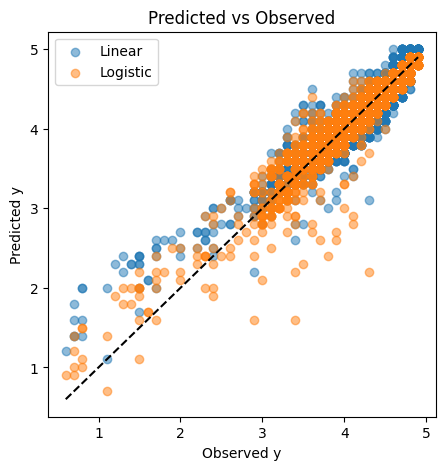

In [ ]:
plt.figure(figsize=(5, 5))

plt.scatter(lin_y, lin_pred, alpha=0.5, label="Linear")
#plt.scatter(enet_y, enet_pred, alpha=0.5, label="Elastic Net")
plt.scatter(lin_log_y, lin_log_pred, alpha=0.5, label="Logistic")
#plt.scatter(enet_log_y, enet_log_pred, alpha=0.5, label="Logistic Elastic")

lims = [y.min(), y.max()]
plt.plot(lims, lims, "k--")

plt.xlabel("Observed y")
plt.ylabel("Predicted y")
plt.legend()
plt.title("Predicted vs Observed")
plt.show()


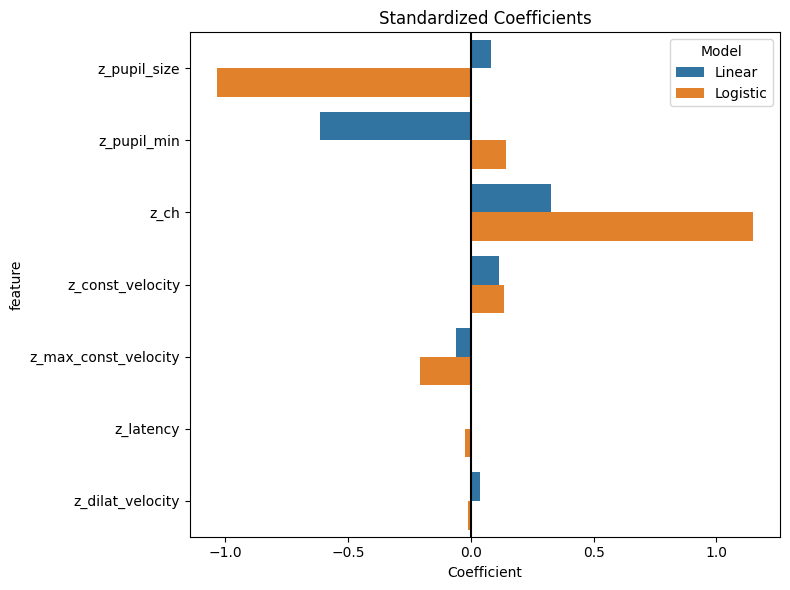

In [17]:
coef_df = pd.DataFrame({
    "feature": FEATURES,
    "Linear": lin_coef,
    "Logistic": lin_log_coef
}).melt(id_vars="feature", var_name="Model", value_name="Coefficient")

plt.figure(figsize=(8, 6))
sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="feature",
    hue="Model"
)
plt.axvline(0, color="black")
plt.title("Standardized Coefficients")
plt.tight_layout()
plt.show()